git add makemore-master/
git commit -m "更新说明"
git push origin main

In [2]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X,Y = [],[]
for w in words[:5]:
    print(w)
    context = [0]*block_size
    for ch in w +'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),'--->',itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


![](images/2026-09-30-14-50-17.png)
![](images/2026-09-30-14-54-17.png)

In [6]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [7]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [8]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [9]:
C = torch.randn((27,2))
C[5]

tensor([-0.0857, -0.1564])

In [10]:
F.one_hot(torch.tensor(5),num_classes = 27).float() @ C


tensor([-0.0857, -0.1564])

![](images/2026-09-30-15-35-12.png)
![](images/2026-09-30-15-33-30.png)
![](images/2026-09-30-15-48-35.png)

In [11]:
emb = C[X]
emb

tensor([[[-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01]],

        [[-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01],
         [-8.5734e-02, -1.5637e-01]],

        [[-5.3008e-01,  2.2791e-01],
         [-8.5734e-02, -1.5637e-01],
         [-2.0795e-03, -2.6142e+00]],

        [[-8.5734e-02, -1.5637e-01],
         [-2.0795e-03, -2.6142e+00],
         [-2.0795e-03, -2.6142e+00]],

        [[-2.0795e-03, -2.6142e+00],
         [-2.0795e-03, -2.6142e+00],
         [-6.8993e-01, -2.8511e-01]],

        [[-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01]],

        [[-5.3008e-01,  2.2791e-01],
         [-5.3008e-01,  2.2791e-01],
         [-9.1448e-02, -1.5874e+00]],

        [[-5.3008e-01,  2.2791e-01],
         [-9.1448e-02, -1.5874e+00],
         [-7.4205e-01, -9.1322e-01]],

        [[-9.1448e-02, -1.5874e+00],
         [-7.4205e-01, -9.1322e-01],
         [ 3.0478e-01,

![](images/2026-09-30-16-44-06.png)
![](images/2026-09-30-16-46-46.png)
![](images/2026-09-30-16-44-15.png)
![](images/2026-10-01-10-28-31.png)

In [12]:
X[13,2]

tensor(1)

In [13]:
C[X][13,2]

tensor([-0.6899, -0.2851])

![](images/2026-09-30-16-53-46.png)
![](images/2026-09-30-16-58-11.png)

In [14]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)
#emb @ W1 + b1

![](images/2026-10-02-10-30-16.png)
![](images/2026-10-02-10-32-27.png)
![](images/2026-10-02-10-33-05.png)

![](images/2026-10-01-10-27-35.png)
![](images/2026-10-01-10-27-56.png)
![](images/2026-10-01-10-06-17.png)
![](images/2026-10-01-10-29-57.png)

In [15]:
torch.cat([emb[:,0,],emb[:,1,],emb[:,2,]],1).shape

torch.Size([32, 6])

![](images/2026-10-01-10-48-10.png)
![](images/2026-10-01-10-52-39.png)
![](images/2026-10-01-10-52-58.png)


In [16]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

![](images/2026-10-01-11-24-29.png)
![](images/2026-10-01-11-22-54.png)
![](images/2026-10-01-11-23-44.png)
![](images/2026-10-01-11-24-57.png) 

In [17]:
emb.view(-1,6)  #emb.view(32,6) or emb.view(emb.shape[0],6)

tensor([[-5.3008e-01,  2.2791e-01, -5.3008e-01,  2.2791e-01, -5.3008e-01,
          2.2791e-01],
        [-5.3008e-01,  2.2791e-01, -5.3008e-01,  2.2791e-01, -8.5734e-02,
         -1.5637e-01],
        [-5.3008e-01,  2.2791e-01, -8.5734e-02, -1.5637e-01, -2.0795e-03,
         -2.6142e+00],
        [-8.5734e-02, -1.5637e-01, -2.0795e-03, -2.6142e+00, -2.0795e-03,
         -2.6142e+00],
        [-2.0795e-03, -2.6142e+00, -2.0795e-03, -2.6142e+00, -6.8993e-01,
         -2.8511e-01],
        [-5.3008e-01,  2.2791e-01, -5.3008e-01,  2.2791e-01, -5.3008e-01,
          2.2791e-01],
        [-5.3008e-01,  2.2791e-01, -5.3008e-01,  2.2791e-01, -9.1448e-02,
         -1.5874e+00],
        [-5.3008e-01,  2.2791e-01, -9.1448e-02, -1.5874e+00, -7.4205e-01,
         -9.1322e-01],
        [-9.1448e-02, -1.5874e+00, -7.4205e-01, -9.1322e-01,  3.0478e-01,
          7.8878e-01],
        [-7.4205e-01, -9.1322e-01,  3.0478e-01,  7.8878e-01, -6.0907e-01,
         -4.0544e-01],
        [ 3.0478e-01,  7.8878e

![](images/2026-10-01-15-58-34.png)
![](images/2026-10-01-15-58-52.png)
![](images/2026-10-01-15-48-45.png)
![](images/2026-10-01-16-02-41.png)

In [18]:
h = torch.tanh(emb.view(-1,6) @W1 + b1)
h

tensor([[ 0.9992,  0.8290,  0.7086,  ..., -0.5938,  0.9892, -0.0445],
        [ 0.9971,  0.9659,  0.9223,  ..., -0.8163,  0.9865,  0.4290],
        [ 1.0000,  0.9998,  0.9969,  ..., -0.9998,  1.0000,  0.5833],
        ...,
        [ 0.9995,  0.8307,  0.8389,  ..., -0.8863,  1.0000, -0.9988],
        [ 0.8956,  0.9732,  0.9837,  ..., -0.3510,  0.7980, -0.1556],
        [ 1.0000,  0.6753, -0.1653,  ..., -0.4357,  0.9996, -0.6079]])

In [19]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts/counts.sum(1,keepdims = True)
loss = -prob[torch.arange(32),Y].log().mean()

![](images/2026-10-02-11-01-56.png)

In [20]:
#整理代码
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,100),generator = g)
b1 = torch.randn(100,generator = g)
W2 = torch.randn((100,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

![](images/2026-10-03-09-30-37.png)
![](images/2026-10-03-09-32-05.png)

In [21]:
sum(p.nelement() for p in parameters)

3481

In [22]:
for p in parameters:
    p.requires_grad = True

In [23]:
for _ in range(10):
    #forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    #counts = logits.exp()
    #probs = counts/counts.sum(1,keepdims = True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1*p.grad

print(loss.item())


4.414664268493652


![](images/2026-10-03-09-39-25.png)
![](images/2026-10-03-09-39-42.png)
![](images/2026-10-03-09-39-50.png)
![](images/2026-10-03-09-42-08.png)

![](images/2026-10-03-10-47-39.png)
![](images/2026-10-03-10-57-41.png)

In [24]:
#前面只取了5个单词，现在取全部！！！
block_size = 3
X,Y = [],[]
for w in words:
    #print(w)
    context = [0]*block_size
    for ch in w +'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context),'--->',itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,100),generator = g)
b1 = torch.randn(100,generator = g)
W2 = torch.randn((100,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]


In [25]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [26]:
sum(p.nelement() for p in parameters)

3481

In [27]:
for p in parameters:
    p.requires_grad = True

In [28]:
#全量梯度下降
for _ in range(10):
    #forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    #counts = logits.exp()
    #probs = counts/counts.sum(1,keepdims = True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1*p.grad

19.505226135253906
17.08449363708496
15.776532173156738
14.833345413208008
14.002610206604004
13.253265380859375
12.57992172241211
11.983107566833496
11.470500946044922
11.051865577697754


In [29]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,100),generator = g)
b1 = torch.randn(100,generator = g)
W2 = torch.randn((100,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True 
#torch.randn(...) 会在内存里重新开辟空间，创建一整套全新的 Tensor 对象。
#因为你调用 torch.randn 时没有指定 requires_grad=True，PyTorch 会给这套全新的 Tensor 赋予默认值 requires_grad = False！


In [30]:
lre = torch.linspace(-3,0,1000) #learning rate exponent 学习率指数
lrs = 10**lre               #learning rate

![](images/2026-10-03-18-02-51.png)
![](images/2026-10-03-18-03-16.png)
![](images/2026-10-07-15-26-33.png)
![](images/2026-10-07-15-27-01.png)
![](images/2026-10-03-18-06-15.png)
![](images/2026-10-03-18-06-27.png)
![](images/2026-10-03-18-07-08.png)

In [ ]:
lri = []
lossi = []

#小批量梯度下降
for i in range(1000):
    #mini-batch construct
    ix = torch.randint(0,X.shape[0],(32,))

    #forward pass
    emb = C[X[ix]]  #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)  #(32,100)
    logits = h @ W2 + b2    #(32,27)
    loss = F.cross_entropy(logits,Y[ix])    
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()
    #update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr*p.grad

    lri.append(lre[i])
    lossi.append(loss.item())
print(loss.item())


7.236630439758301


![](images/2026-10-03-15-01-49.png)
![](images/2026-10-03-15-10-47.png)
![](images/2026-10-03-15-03-30.png)

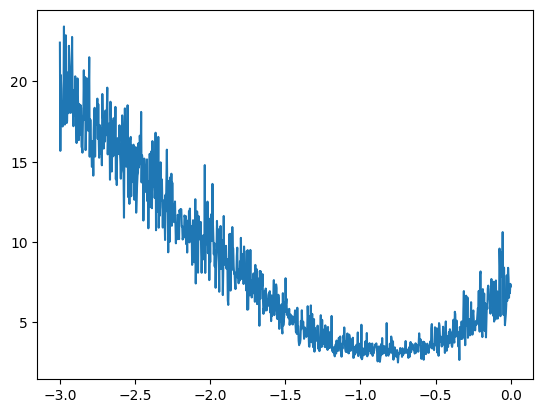

In [32]:
plt.plot(lri,lossi);

![](images/2026-10-03-19-53-11.png)

In [33]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Y)
loss

tensor(7.1404, grad_fn=<NllLossBackward0>)

#训练集、开发集/验证集、测试集
![](images/2026-10-03-20-57-45.png)
![](images/2026-10-03-20-58-34.png)
![](images/2026-10-03-20-59-15.png)
![](images/2026-10-03-21-03-16.png) 